In [158]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [159]:
distances = np.array([[0, 1, 0.9, 3],
                        [1, 0, 2, 0.8],
                        [0.9, 2, 0, 0.5],
                        [3, 0.8, 0.5, 0]])

In [160]:
def check_valid_solution(key_string):
    state = [int(key_string[k]) for k in range(len(key_string))]
    state = np.reshape(state, (4,4))
    timeConstraints = np.sum(state,axis=0)
    spaceConstraints = np.sum(state,axis=1)
    return np.array_equal(spaceConstraints,np.ones(4,dtype=int)) and np.array_equal(timeConstraints,np.ones(4,dtype=int))
def key_to_sol(key_string):
    state = [int(key_string[k]) for k in range(len(key_string))]
    state = np.reshape(list(reversed(state)), (4,4))
    if not check_valid_solution(key_string):
        return None
    sol = [np.where(state.T[i] == 1)[0].tolist()[0] for i in range(4)]
    return sol

def costFunction(key_string):
    sol = key_to_sol(key_string)
    if sol is None:
        return 1e6
    cost = 0
    for t in range(4):
        cost += distances[sol[t],sol[(t+1) % 4]]
    return cost

In [ ]:
HBAR=1

def trotterize_H_0(time:float)->QuantumCircuit:
    qc = QuantumCircuit(16)
    for i in range(16):
        qc.rx(-2*time/HBAR,i)
    return qc

def trotterize_H_P_2(time:float):
    #À partir de mon commentaire en gras

    ALPHA = 10
    BETA = 10
    GAMMA = 10

    qc = QuantumCircuit(16)

    #Fonction de coût
    for i in range(4):
        for t in range(4):
            angle=(-1)*np.sum(distances[i,:])/2*time
            qc.rz(angle,(4*i)+t)

    for j in range(4):
        for t in range(4):
            angle=(-1)*np.sum(distances[:,j])/2*time
            qc.rz(angle,(4*j)+t)
    
    for i in range(4):
        for j in range(4):
            for t in range(4):
                angle=distances[i,j]*time/2
                qc.cx((4*i)+t,(4*j)+((t+1)%4))
                qc.rz(angle,(4*j)+((t+1)%4))
                qc.cx((4*i)+t,(4*j)+((t+1)%4))


    #Contrainte commencer à 1
    qc.rz(GAMMA*time,0)

    #Contrainte sommet visité une seule fois
    angle=(-2)*ALPHA*time
    for i in range(4):
        for t in range(4):
            qc.rz(angle,(4*i)+t)

    angle=ALPHA*time
    for i in range(4):
        for t_1 in range(4):
            for t_2 in range(t_1+1,4):
                qc.cx((4*i)+t_1,(4*i)+t_2)
                qc.rz(angle,(4*i)+t_2)
                qc.cx((4*i)+t_1,(4*i)+t_2)
    
    #Contrainte un temps par sommet
    angle=(-2)*ALPHA*time
    for i in range(4):
        for t in range(4):
            qc.rz(angle,(4*i)+t)

    angle=ALPHA*time
    for t in range(4):
        for i in range(4):
            for j in range(i+1,4):
                qc.cx((4*i)+t,(4*j)+t)
                qc.rz(angle,(4*j)+t)
                qc.cx((4*i)+t,(4*j)+t)

    
    return qc


    




def trotterize_H_P(time:float)->QuantumCircuit:

    ALPHA = 10
    BETA = 10
    GAMMA = 10

    cst=(ALPHA+BETA)*-1 #N=4

    qc = QuantumCircuit(16)

    # on ne tient pas compte de la phase global avec le terme selon l'identité dans H

    # Terme Z_i,t
    for i in range(4):
        angle=2*(cst-0.5*(np.sum(distances[i,:])))*time/HBAR
        for t in range(4):
            qc.rz(angle,(i*4)+t)
            
    
    # Terme Z_i,t * Z_j,t+1
    for i in range(4):
        for j in range(i+1,4):
            angle= distances[i,j]*time/(2*HBAR)
            for t in range(4):
                qc.cx(4*i+t,4*j+((t+1)%4))
                qc.rz(angle,4*j+((t+1)%4))
                qc.cx(4*i+t,4*j+((t+1)%4))
    
    
    # Terme Z_1,1
    angle=GAMMA*time/(HBAR)
    qc.rz(angle,0)

    angle=ALPHA*time/(HBAR)
    for i in range(4):
        for t_1 in range(4):
            for t_2 in range(t_1+1,4):
                qc.cx(4*i+t_1,4*i+t_2)
                qc.rz(angle,4*i+t_2)
                qc.cx(4*i+t_1,4*i+t_2)


    angle=BETA*time/(HBAR)
    for t in range(4):
        for i in range(4):
            for j in range(i+1,4):
                qc.cx(4*i+t,4*j+t)
                qc.rz(angle,4*j+t)
                qc.cx(4*i+t,4*j+t)
    
    return qc



def circuit(M,T):

    dt=T/M
    qc = QuantumCircuit(16)

    #Préparer l'état fondamental de H_i=-\sum_{i,j}^NX_{i,j} qui est l'état |+>^{N^2}
    qc.h([i for i in range(16)])

    for j in range(M):
        s = j / M
        qc.append(trotterize_H_0((1-s)*dt/2),[i for i in range(16)])
        qc.append(trotterize_H_P_2(s * dt),[i for i in range(16)])
        qc.append(trotterize_H_0((1-s)*dt/2),[i for i in range(16)])

        # enregistrer le circuit pour une itération
        # if j == 2:
        #     fig = qc.decompose(reps=1).draw(output='mpl', scale=0.7)
        #     fig.savefig("test.pdf", bbox_inches="tight")
        #     plt.close(fig)

    return qc


In [162]:
qcSol = circuit(300,20)
state = Statevector.from_instruction(qcSol)
dictState = state.probabilities_dict()

In [163]:
maxKey = max(dictState, key=dictState.get)
maxProb = dictState[maxKey]
print("État le plus probable:", maxKey, "avec une probabilité de", maxProb)

État le plus probable: 0100001010000001 avec une probabilité de 0.16583264296441053


Solution valide trouvée: [0, 2, 3, 1]  avec coût 3.2 et fréquence 0.16583264296441053
Solution valide trouvée: [0, 2, 1, 3]  avec coût 6.7 et fréquence 0.14921730281555162
Solution valide trouvée: [0, 1, 3, 2]  avec coût 3.1999999999999997 et fréquence 0.1402474327385955
Solution valide trouvée: [0, 3, 2, 1]  avec coût 6.5 et fréquence 0.09205130099647055
Solution valide trouvée: [0, 1, 2, 3]  avec coût 6.5 et fréquence 0.07344611594048574
Solution valide trouvée: [0, 3, 1, 2]  avec coût 6.7 et fréquence 0.037159352036218125


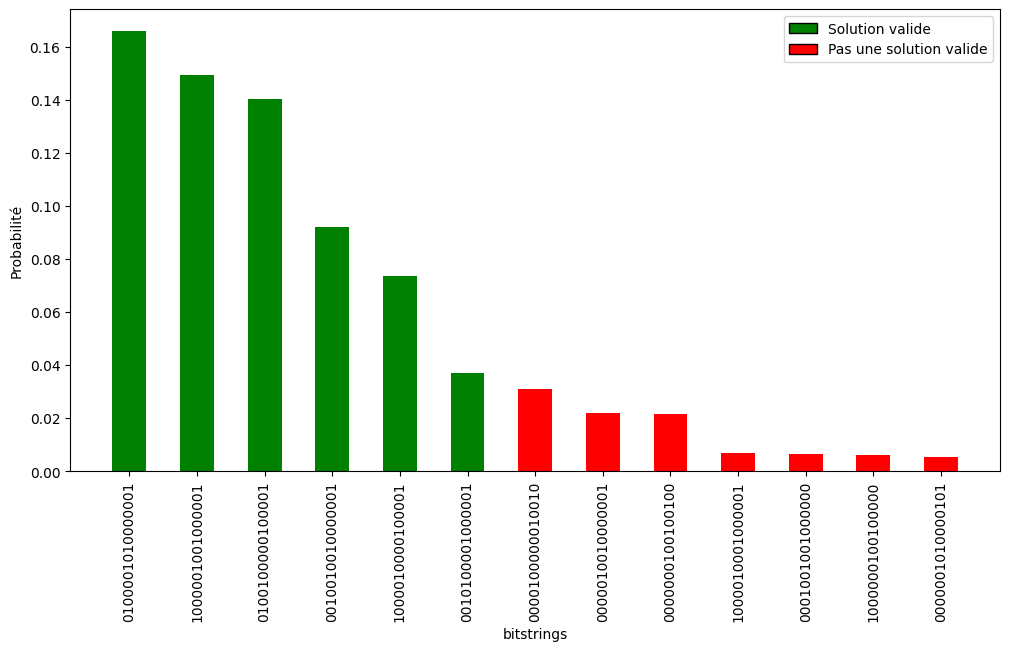

In [164]:
most_freq = {k: v for k, v in dictState.items() if v > 0.005}
sorted_dict = dict(sorted(most_freq.items(), key=lambda item: item[1], reverse=True))
color_dict = {}
found_best_bitstrings = []
countsGoodSolution = 0 
for key in sorted_dict:
    if check_valid_solution(key):
        print("Solution valide trouvée:", key_to_sol(key)," avec coût", costFunction(key), "et fréquence", sorted_dict[key])
        color_dict.update({key : "g"})
        countsGoodSolution += sorted_dict[key]
    else:
        color_dict.update({key : "r"})
plt.figure(figsize=(12, 6))
plt.xlabel("bitstrings")
plt.ylabel("Probabilité")
plt.bar(sorted_dict.keys(), np.array(list(sorted_dict.values())), width=0.5, color=color_dict.values())
plt.xticks(rotation="vertical")
#create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in ['g','r']]
labels= ["Solution valide", "Pas une solution valide"]
plt.legend(handles, labels)

plt.savefig("histogramme.pdf")
plt.show()